<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
SalimosHoy? - Proceso final de dataset, modelos y decision tecnica
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Este notebook documenta el proceso final usado para construir <span style="color:#D11A2A; font-weight:700;">SalimosHoy?</span>. 
    El objetivo es mostrar la toma de decisiones: cambio de nombre, actividades oficiales, construccion del dataset v2, comparacion de modelos, seleccion del modelo ligero para GitHub/demo y respaldo tecnico con modelos mas grandes. 
    El notebook esta pensado como evidencia tecnica del proyecto y <span style="color:#D11A2A; font-weight:700;">no guarda CSVs nuevos de resultados de modelos</span>.
  </p>
</div>

<div style="
  background: #ececec;
  border-left: 6px solid #f59e0b;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Idea clave para defender el proyecto: <span style="color:#D11A2A; font-weight:700;">el modelo no predice el clima</span>. 
    Open-Meteo entrega los datos climaticos. SalimosHoy? usa esos datos para clasificar si una hora es mala, regular, buena o excelente para una actividad.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 1 - Configuracion, imports y rutas
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este bloque preparo las librerias, rutas y parametros principales. Las rutas estan pensadas para ejecutarse desde la carpeta raiz del proyecto. 
    Si se usa Google Colab, primero se debe subir o montar el proyecto completo en Drive.
  </p>
</div>

In [ ]:
from pathlib import Path
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

warnings.filterwarnings("ignore")

# Ruta raiz esperada del proyecto.
PROJECT_ROOT = Path.cwd()

# Dataset completo usado en la investigacion tecnica.
DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "salimoshoy_full_dataset.csv"

# Modelo ligero oficial usado por la demo/GitHub.
PRODUCTION_MODEL_PATH = PROJECT_ROOT / "models" / "light" / "salimoshoy_rf_100_depth16_compressed.pkl"

# Este notebook no guarda CSVs nuevos de resultados.
SAVE_MODEL_REPORTS = False

# Muestra recomendada para una prueba reproducible moderada.
SAMPLE_SIZE = 600_000

print("Ruta del proyecto:", PROJECT_ROOT)
print("Dataset esperado:", DATASET_PATH)
print("Modelo de produccion esperado:", PRODUCTION_MODEL_PATH)

Ruta del proyecto: c:\Users\Masacre\Desktop\SalimosHoy_final_github_demo
Dataset esperado: c:\Users\Masacre\Desktop\SalimosHoy_final_github_demo\data\processed\salimoshoy_full_dataset.csv
Modelo de produccion esperado: c:\Users\Masacre\Desktop\SalimosHoy_final_github_demo\models\light\salimoshoy_rf_100_depth16_compressed.pkl


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Queda definida la ruta del dataset completo y del modelo ligero final. El notebook permite documentar resultados aunque no se ejecute el entrenamiento pesado. 
    Si el dataset no esta disponible en la ruta indicada, las tablas de decisiones historicas permiten mostrar el proceso seguido.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 2 - Estilo visual para tablas
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Uso una funcion de estilo para que las tablas del notebook sean mas claras. Esto mejora la lectura de distribuciones, comparativas de modelos y metricas finales.
  </p>
</div>

In [2]:
def style_table(styler):
    return (
        styler
        .set_table_styles(
            [
                {
                    "selector": "thead th",
                    "props": [
                        ("background-color", "#0f172a"),
                        ("color", "white"),
                        ("font-weight", "bold"),
                        ("text-align", "center"),
                        ("border", "1px solid #334155"),
                        ("padding", "8px"),
                    ],
                },
                {
                    "selector": "tbody td",
                    "props": [
                        ("border", "1px solid #cbd5e1"),
                        ("padding", "8px"),
                        ("text-align", "center"),
                    ],
                },
                {
                    "selector": "tbody th",
                    "props": [
                        ("border", "1px solid #cbd5e1"),
                        ("padding", "8px"),
                        ("text-align", "center"),
                        ("background-color", "#f1f5f9"),
                    ],
                },
                {
                    "selector": "tbody tr:nth-child(even)",
                    "props": [("background-color", "#f8fafc")],
                },
                {
                    "selector": "tbody tr:nth-child(odd)",
                    "props": [("background-color", "#ffffff")],
                },
            ]
        )
        .set_properties(**{"font-size": "14px", "color": "#111827"})
    )

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Esta funcion no cambia los datos. Solo mejora la forma en que se muestran las tablas dentro del notebook.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 3 - Decisiones finales del proyecto
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En esta etapa el proyecto dejo de llamarse OutByML y paso a llamarse <span style="color:#D11A2A; font-weight:700;">SalimosHoy?</span>. 
    Tambien se reemplazaron las actividades iniciales por seis actividades oficiales nuevas. Esa decision obligo a limpiar el proyecto, regenerar dataset y reentrenar el modelo.
  </p>
</div>

In [18]:
official_activities = [
    "Pasear o hacer senderismo",
    "Jardineria y agricultura",
    "Deportes al aire libre",
    "Picnic o actividades en parque",
    "Ir al cine",
    "Ir a la playa",
]

removed_activities = [
    "Bici",
    "Deporte",
    "Lavar ropa",
    "Pasear",
    "Turismo",
    "Esquiar o deportes de invierno",
]

decisions = pd.DataFrame(
    [
        ["Nombre final", "SalimosHoy?", "Evitar mezcla con el nombre anterior y presentar identidad final."],
        ["Actividades oficiales", "6 actividades nuevas", "Alinear app, dataset, modelo y README."],
        ["Dataset final", "200 ciudades + 6 meses estrategicos", "Se decidio aumentar diversidad del Dataset."],
        ["Modelo de demo/GitHub", "RandomForest ligero comprimido", "Mantener alto rendimiento sin subir un archivo enorme a GitHub."],
        ["Modelo full", "Entrenado como respaldo tecnico", "Mostrar que tambien se valido el entrenamiento con todo el dataset."],
    ],
    columns=["decision", "valor", "motivo"],
)

display(style_table(decisions.style))

,decision,valor,motivo
0,Nombre final,SalimosHoy?,Evitar mezcla con el nombre anterior y presentar identidad final.
1,Actividades oficiales,6 actividades nuevas,"Alinear app, dataset, modelo y README."
2,Dataset final,200 ciudades + 6 meses estrategicos,Se decidio aumentar diversidad del Dataset.
3,Modelo de demo/GitHub,RandomForest ligero comprimido,Mantener alto rendimiento sin subir un archivo enorme a GitHub.
4,Modelo full,Entrenado como respaldo tecnico,Mostrar que tambien se valido el entrenamiento con todo el dataset.


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Estas decisiones explican por que fue necesario reconstruir el flujo. El modelo anterior ya no era valido porque habia sido entrenado con actividades antiguas. 
    La version final mantiene coherencia entre app, dataset, modelo y documentacion.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 4 - Fuente de datos y APIs utilizadas
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    SalimosHoy? usa Open-Meteo de dos formas: la app consulta clima actualizado y el dataset se construyo con datos historicos. 
    Esto permite separar claramente dos tareas: obtener clima y clasificar si ese clima conviene para una actividad.
  </p>
</div>

In [4]:
apis_used = pd.DataFrame(
    [
        ["Open-Meteo Geocoding API", "Convierte ciudad en coordenadas y zona horaria.", "App"],
        ["Open-Meteo Forecast API", "Obtiene clima actualizado por hora.", "App"],
        ["Open-Meteo Historical Weather API", "Obtiene clima historico horario para construir el dataset.", "Dataset"],
    ],
    columns=["api", "uso", "parte_del_proyecto"],
)

display(style_table(apis_used.style))

,api,uso,parte_del_proyecto
0,Open-Meteo Geocoding API,Convierte ciudad en coordenadas y zona horaria.,App
1,Open-Meteo Forecast API,Obtiene clima actualizado por hora.,App
2,Open-Meteo Historical Weather API,Obtiene clima historico horario para construir el dataset.,Dataset


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo no reemplaza a Open-Meteo. Open-Meteo entrega las variables climaticas y el modelo aprende a clasificar esas condiciones para una actividad concreta.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 5 - Estrategia del dataset final
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El dataset final usa <span style="color:#D11A2A; font-weight:700;">200 ciudades</span> y <span style="color:#D11A2A; font-weight:700;">6 meses estrategicos</span>. 
    No se eligieron datos al azar: se uso muestreo estrategico para incluir diversidad geografica y temporal.
  </p>
</div>

In [5]:
dataset_strategy = pd.DataFrame(
    [
        ["Ciudades", "200", "Aumentar diversidad geografica y grupos climaticos."],
        ["Meses estrategicos", "enero, marzo, mayo, julio, septiembre, noviembre", "Capturar variacion temporal sin generar un dataset innecesariamente pesado."],
        ["Actividades", "6", "Cubrir actividades exteriores, interiores y recreativas."],
        ["Registros finales", "3,054,400", "Base amplia para entrenamiento y validacion."],
        ["Nulos", "0", "El dataset final quedo limpio para modelado."],
    ],
    columns=["elemento", "valor", "justificacion"],
)

display(style_table(dataset_strategy.style))

,elemento,valor,justificacion
0,Ciudades,200,Aumentar diversidad geografica y grupos climaticos.
1,Meses estrategicos,"enero, marzo, mayo, julio, septiembre, noviembre",Capturar variacion temporal sin generar un dataset innecesariamente pesado.
2,Actividades,6,"Cubrir actividades exteriores, interiores y recreativas."
3,Registros finales,"3,054,400",Base amplia para entrenamiento y validacion.
4,Nulos,0,El dataset final quedo limpio para modelado.


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La seleccion de meses estrategicos no es manipulacion del dataset. Es una forma de cubrir estaciones y contextos climaticos distintos con un volumen manejable.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 6 - Carga y revision del dataset final
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Este bloque carga el dataset final si esta disponible. Si no esta en el entorno, se muestran los resultados finales conocidos para documentar el proceso.
  </p>
</div>

In [6]:
if DATASET_PATH.exists():
    df = pd.read_csv(DATASET_PATH)
    print("Dataset cargado correctamente.")
    print("Filas y columnas:", df.shape)

    nulls_table = df.isna().sum().reset_index()
    nulls_table.columns = ["column", "missing_values"]
    display(style_table(nulls_table.style.bar(subset=["missing_values"], color="#f87171")))

    recommendation_distribution = (
        df["recommendation"]
        .value_counts()
        .rename_axis("recommendation")
        .reset_index(name="count")
    )
    recommendation_distribution["percentage"] = (
        recommendation_distribution["count"] / recommendation_distribution["count"].sum() * 100
    ).round(2)

else:
    print("IMPORTANTE: No se encontro el dataset completo en la ruta esperada.")
    print("Se muestran los resultados finales documentados del dataset v2.")

    df = None
    recommendation_distribution = pd.DataFrame(
        [
            ["excelente", 1457559, 47.72],
            ["bueno", 846349, 27.71],
            ["regular", 495985, 16.24],
            ["malo", 254507, 8.33],
        ],
        columns=["recommendation", "count", "percentage"],
    )

display(
    style_table(
        recommendation_distribution.style
        .format({"percentage": "{:.2f}%"})
        .bar(subset=["percentage"], color="#38bdf8")
    )
)

IMPORTANTE: No se encontro el dataset completo en la ruta esperada.
Se muestran los resultados finales documentados del dataset v2.


,recommendation,count,percentage
0,excelente,1457559,47.72%
1,bueno,846349,27.71%
2,regular,495985,16.24%
3,malo,254507,8.33%


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La distribucion final es razonable porque todas las clases quedan representadas. La clase malo supera el 5%, por lo que el modelo puede aprender tambien condiciones no recomendables.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 7 - Distribucion por actividad
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En esta seccion reviso si las actividades oficiales generan comportamientos coherentes. Actividades exteriores como playa y deportes deben ser mas sensibles al clima que ir al cine.
  </p>
</div>

In [7]:
if df is not None:
    activity_distribution = (
        df.groupby(["activity", "recommendation"])
        .size()
        .reset_index(name="count")
    )
    activity_distribution["percentage"] = (
        activity_distribution["count"] /
        activity_distribution.groupby("activity")["count"].transform("sum") * 100
    ).round(2)
else:
    activity_distribution = pd.DataFrame(
        [
            ["Deportes al aire libre", "bueno", 243154, None],
            ["Deportes al aire libre", "excelente", 126853, None],
            ["Deportes al aire libre", "malo", 76834, None],
            ["Deportes al aire libre", "regular", 141959, None],
            ["Ir a la playa", "bueno", 114431, None],
            ["Ir a la playa", "excelente", 120794, None],
            ["Ir a la playa", "malo", 65787, None],
            ["Ir a la playa", "regular", 177388, None],
            ["Ir al cine", "bueno", 21137, None],
            ["Ir al cine", "excelente", 494063, None],
            ["Jardineria y agricultura", "bueno", 124582, None],
            ["Jardineria y agricultura", "excelente", 228159, None],
            ["Jardineria y agricultura", "malo", 37169, None],
            ["Jardineria y agricultura", "regular", 88490, None],
            ["Pasear o hacer senderismo", "bueno", 202905, None],
            ["Pasear o hacer senderismo", "excelente", 261530, None],
            ["Pasear o hacer senderismo", "malo", 41329, None],
            ["Pasear o hacer senderismo", "regular", 46236, None],
            ["Picnic o actividades en parque", "bueno", 140140, None],
            ["Picnic o actividades en parque", "excelente", 226160, None],
            ["Picnic o actividades en parque", "malo", 33388, None],
            ["Picnic o actividades en parque", "regular", 41912, None],
        ],
        columns=["activity", "recommendation", "count", "percentage"]
    )
    activity_distribution["percentage"] = (
        activity_distribution["count"] /
        activity_distribution.groupby("activity")["count"].transform("sum") * 100
    ).round(2)

display(
    style_table(
        activity_distribution.style
        .format({"percentage": "{:.2f}%"})
        .bar(subset=["percentage"], color="#38bdf8")
    )
)

,activity,recommendation,count,percentage
0,Deportes al aire libre,bueno,243154,41.30%
1,Deportes al aire libre,excelente,126853,21.54%
2,Deportes al aire libre,malo,76834,13.05%
3,Deportes al aire libre,regular,141959,24.11%
4,Ir a la playa,bueno,114431,23.92%
5,Ir a la playa,excelente,120794,25.25%
6,Ir a la playa,malo,65787,13.75%
7,Ir a la playa,regular,177388,37.08%
8,Ir al cine,bueno,21137,4.10%
9,Ir al cine,excelente,494063,95.90%


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La actividad <span style="color:#D11A2A; font-weight:700;">Ir al cine</span> queda mayormente en excelente porque es una actividad interior. 
    En cambio, playa, deportes al aire libre, picnic y senderismo son mas sensibles a lluvia, viento, temperatura y UV.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 8 - Visualizacion de la variable objetivo
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La grafica ayuda a ver rapidamente si el dataset esta demasiado cargado hacia una sola clase.
  </p>
</div>

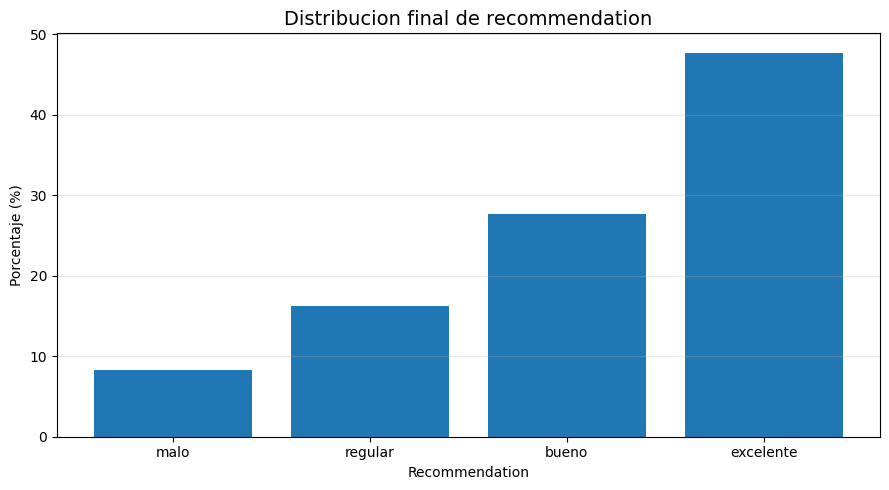

In [17]:
plot_distribution = recommendation_distribution.copy()
order = ["malo", "regular", "bueno", "excelente"]
plot_distribution["recommendation"] = pd.Categorical(plot_distribution["recommendation"], categories=order, ordered=True)
plot_distribution = plot_distribution.sort_values("recommendation")

plt.figure(figsize=(9, 5))
plt.bar(plot_distribution["recommendation"].astype(str), plot_distribution["percentage"])
plt.title("Distribucion final de recommendation", fontsize=14)
plt.xlabel("Recommendation")
plt.ylabel("Porcentaje (%)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La distribucion final permite entrenar un modelo supervisado porque ninguna clase queda practicamente invisible. Esto fue una mejora clave frente a las primeras versiones del dataset.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 9 - Variables usadas para Machine Learning
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aqui se separan las variables de entrada y la variable objetivo. No se usan <span style="color:#D11A2A; font-weight:700;">activity_score</span> ni <span style="color:#D11A2A; font-weight:700;">comfort_distance</span> como features para evitar fuga de informacion.
  </p>
</div>

In [9]:
target = "recommendation"

numeric_features = [
    "temperature_2m",
    "apparent_temperature",
    "relative_humidity_2m",
    "precipitation_probability",
    "wind_speed_10m",
    "wind_gusts_10m",
    "cloud_cover",
    "uv_index",
    "hour",
]

categorical_features = [
    "activity",
    "continent",
    "climate_group",
    "season_block",
]

features = numeric_features + categorical_features

features_table = pd.DataFrame({
    "tipo": ["numerica"] * len(numeric_features) + ["categorica"] * len(categorical_features),
    "feature": features
})

display(style_table(features_table.style))

,tipo,feature
0,numerica,temperature_2m
1,numerica,apparent_temperature
2,numerica,relative_humidity_2m
3,numerica,precipitation_probability
4,numerica,wind_speed_10m
5,numerica,wind_gusts_10m
6,numerica,cloud_cover
7,numerica,uv_index
8,numerica,hour
9,categorica,activity


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Estas 13 variables son las usadas para crear la app y entrenar el modelo.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 10 - Resultados de modelos usados durante el proyecto
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Durante el proyecto se probaron varias fases de modelado. Primero se entrenaron modelos con muestras grandes y despues se optimizo una version ligera para GitHub/demo.
  </p>
</div>

In [10]:
model_phase_results = pd.DataFrame(
    [
        ["RandomForest 600k", "600,000 filas", 0.998921, 0.996492, 0.002429, "Primer candidato fuerte"],
        ["RandomForest 1M", "1,000,000 filas", 0.999580, 0.997925, 0.001655, "Modelo pesado de produccion local"],
        ["RandomForest full", "3,054,400 filas", 0.999568, 0.998934, 0.000634, "Respaldo tecnico con dataset completo"],
        ["RF_100_depth16 comprimido", "600,000 filas", None, 0.994267, None, "Modelo ligero elegido para GitHub/demo"],
    ],
    columns=["modelo", "datos_usados", "accuracy_train", "accuracy_test", "difference_train_test", "uso"],
)

display(
    style_table(
        model_phase_results.style
        .format({
            "accuracy_train": lambda x: "" if pd.isna(x) else f"{x:.6f}",
            "accuracy_test": "{:.6f}",
            "difference_train_test": lambda x: "" if pd.isna(x) else f"{x:.6f}",
        })
        .bar(subset=["accuracy_test"], color="#38bdf8")
    )
)

,modelo,datos_usados,accuracy_train,accuracy_test,difference_train_test,uso
0,RandomForest 600k,"600,000 filas",0.998921,0.996492,0.002429,Primer candidato fuerte
1,RandomForest 1M,"1,000,000 filas",0.999580,0.997925,0.001655,Modelo pesado de produccion local
2,RandomForest full,"3,054,400 filas",0.999568,0.998934,0.000634,Respaldo tecnico con dataset completo
3,RF_100_depth16 comprimido,"600,000 filas",,0.994267,,Modelo ligero elegido para GitHub/demo


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo full tuvo la mejor metrica tecnica, pero era innecesariamente pesado para GitHub/demo. 
    Por eso se eligio un modelo comprimido de 28.49 MB, con accuracy_test 0.994267 y recall muy alto en las clases criticas.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 11 - Comparacion entre familias de modelos
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Ademas de RandomForest, se probaron modelos de referencia para justificar la decision final. 
    El objetivo fue comparar un modelo simple, un modelo lineal y modelos basados en ensambles de arboles.
  </p>
</div>

In [11]:
family_results = pd.DataFrame(
    [
        ["DecisionTreeClassifier", "baseline interpretable", 0.938717, "Bueno como referencia, pero menor rendimiento."],
        ["LogisticRegression", "modelo lineal", 0.5017, "No separa bien clases no lineales del problema."],
        ["ExtraTreesClassifier", "ensamble alternativo", 0.914167, "No supero a RandomForest en esta version."],
        ["RandomForestClassifier", "ensamble principal", 0.996492, "Mejor equilibrio inicial en la fase de 600k."],
    ],
    columns=["modelo", "tipo", "accuracy_test", "lectura"]
)

display(
    style_table(
        family_results.style
        .format({"accuracy_test": "{:.6f}"})
        .bar(subset=["accuracy_test"], color="#38bdf8")
    )
)

,modelo,tipo,accuracy_test,lectura
0,DecisionTreeClassifier,baseline interpretable,0.938717,"Bueno como referencia, pero menor rendimiento."
1,LogisticRegression,modelo lineal,0.501700,No separa bien clases no lineales del problema.
2,ExtraTreesClassifier,ensamble alternativo,0.914167,No supero a RandomForest en esta version.
3,RandomForestClassifier,ensamble principal,0.996492,Mejor equilibrio inicial en la fase de 600k.


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La comparacion muestra que el problema no se resolvia bien con un modelo lineal. Los modelos basados en arboles capturaron mejor la relacion entre clima, actividad, hora y recomendacion.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 12 - Seleccion del modelo ligero para GitHub/demo
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo de 1M funcionaba muy bien, pero pesaba demasiado para GitHub. Por eso se entrenaron versiones mas ligeras y comprimidas.
  </p>
</div>

In [12]:
light_model_results = pd.DataFrame(
    [
        ["RF_100_depth16", 28.49, 0.994267, 0.992699, 0.992456, "Si", "Elegido"],
        ["RF_80_depth14", 13.45, 0.985633, 0.990299, 0.988248, "Si", "Alternativa ligera"],
        ["RF_60_depth14", 10.14, 0.984417, 0.989699, 0.987376, "Si", "Alternativa ligera"],
        ["RF_50_depth12", 4.42, 0.959617, 0.984998, 0.969773, "No", "Pierde rendimiento"],
    ],
    columns=["modelo", "peso_mb", "accuracy_test", "recall_malo", "recall_regular", "cumple_criterio", "decision"],
)

display(
    style_table(
        light_model_results.style
        .format({
            "peso_mb": "{:.2f} MB",
            "accuracy_test": "{:.6f}",
            "recall_malo": "{:.6f}",
            "recall_regular": "{:.6f}",
        })
        .bar(subset=["accuracy_test"], color="#38bdf8")
    )
)

,modelo,peso_mb,accuracy_test,recall_malo,recall_regular,cumple_criterio,decision
0,RF_100_depth16,28.49 MB,0.994267,0.992699,0.992456,Si,Elegido
1,RF_80_depth14,13.45 MB,0.985633,0.990299,0.988248,Si,Alternativa ligera
2,RF_60_depth14,10.14 MB,0.984417,0.989699,0.987376,Si,Alternativa ligera
3,RF_50_depth12,4.42 MB,0.959617,0.984998,0.969773,No,Pierde rendimiento


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La decision final fue usar <span style="color:#D11A2A; font-weight:700;">RF_100_depth16</span> porque mantiene metricas muy altas y pesa solo 28.49 MB. 
    Este modelo es el mas equilibrado para una demo en GitHub.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 13 - Entrenamiento opcional reproducible
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Este bloque permite reentrenar modelos si se desea, pero por defecto queda desactivado para no consumir tiempo innecesario en Colab. 
    No guarda CSVs de resultados: solo muestra metricas en pantalla.
  </p>
</div>

In [ ]:
# Si se quiere reentrenar dentro del notebook, cambiar a True.
# Por defecto queda en False para evitar ejecuciones largas en Colab.
RUN_TRAINING = False

if RUN_TRAINING:
    if df is None:
        raise FileNotFoundError("No se puede entrenar porque no se encontro el dataset completo.")

    def make_stratified_sample(data, target_col, sample_size, random_state=42):
        if sample_size >= len(data):
            return data.copy()

        fractions = sample_size / len(data)
        return (
            data
            .groupby(target_col, group_keys=False)
            .sample(frac=fractions, random_state=random_state)
            .reset_index(drop=True)
        )

    sample_df = make_stratified_sample(df, target, SAMPLE_SIZE, random_state=42)

    X = sample_df[features].copy()
    y = sample_df[target].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
    categorical_transformer = Pipeline(steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))])

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features),
        ]
    )

    models_to_train = {
        "DecisionTreeClassifier": DecisionTreeClassifier(
            max_depth=10,
            class_weight="balanced",
            random_state=42
        ),
        "RandomForestClassifier": RandomForestClassifier(
            n_estimators=100,
            max_depth=16,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
        "ExtraTreesClassifier": ExtraTreesClassifier(
            n_estimators=100,
            max_depth=16,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
    }

    training_results = []

    for model_name, estimator in models_to_train.items():
        model = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", estimator),
            ]
        )

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        training_results.append(
            {
                "model": model_name,
                "accuracy_train": accuracy_score(y_train, y_train_pred),
                "accuracy_test": accuracy_score(y_test, y_test_pred),
                "difference_train_test": accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred),
            }
        )

        print("\nModelo:", model_name)
        print(classification_report(y_test, y_test_pred, labels=["malo", "regular", "bueno", "excelente"]))

    training_results_df = pd.DataFrame(training_results).sort_values("accuracy_test", ascending=False)
    display(
        style_table(
            training_results_df.style
            .format({
                "accuracy_train": "{:.6f}",
                "accuracy_test": "{:.6f}",
                "difference_train_test": "{:.6f}",
            })
            .bar(subset=["accuracy_test"], color="#38bdf8")
        )
    )

else:
    print("Entrenamiento desactivado. Cambia RUN_TRAINING = True si quieres reentrenar modelos en este notebook.")

Entrenamiento desactivado. Cambia RUN_TRAINING = True si quieres reentrenar modelos en este notebook.


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Este bloque deja el entrenamiento como evidencia reproducible sin obligar a ejecutarlo cada vez. 
    Los resultados principales del proyecto ya estan documentados en las tablas anteriores.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 14 - Validacion del modelo oficial de demo/GitHub
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este bloque se carga el modelo ligero oficial si esta disponible. Esto comprueba que el archivo que usa la app puede abrirse y hacer predicciones.
  </p>
</div>

In [14]:
if PRODUCTION_MODEL_PATH.exists():
    production_model = joblib.load(PRODUCTION_MODEL_PATH)
    print("Modelo cargado correctamente:")
    print(PRODUCTION_MODEL_PATH)

    if df is not None:
        sample_X = df[features].head(10).copy()
        sample_predictions = production_model.predict(sample_X)

        prediction_table = sample_X.copy()
        prediction_table["predicted_recommendation"] = sample_predictions

        display(style_table(prediction_table.style))
    else:
        print("El modelo existe, pero no hay dataset cargado para mostrar predicciones de ejemplo.")
else:
    print("IMPORTANTE: No se encontro el modelo oficial de demo/GitHub en la ruta esperada.")
    print(PRODUCTION_MODEL_PATH)

Modelo cargado correctamente:
c:\Users\Masacre\Desktop\SalimosHoy_final_github_demo\models\light\salimoshoy_rf_100_depth16_compressed.pkl
El modelo existe, pero no hay dataset cargado para mostrar predicciones de ejemplo.


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo oficial de demo/GitHub esta pensado para ser liviano y facil de subir al repositorio. 
    Su rendimiento se mantiene alto y su peso es razonable para una app Streamlit.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 15 - Limitaciones y decisiones honestas
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #f59e0b;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    SalimosHoy? no sustituye una app meteorologica profesional. La calidad del clima depende de Open-Meteo. 
    El modelo clasifica condiciones para una actividad, pero no simula la atmosfera ni predice el clima desde cero. 
    El dataset fue construido con ciudades y meses estrategicos para cubrir variedad, pero aun podria ampliarse con mas paises, mas años y validacion externa.
  </p>
</div>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Tambien se entreno un modelo full con todo el dataset, pero para GitHub/demo se eligio el modelo ligero. 
    Esta decision reduce peso y facilita despliegue sin perder rendimiento critico. 
    El modelo full queda como respaldo tecnico para demostrar que el dataset completo fue utilizado en la fase de investigacion.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Bloque 16 - Conclusion final del proceso
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El proyecto final queda estructurado como una solucion completa: una app web que consulta clima actualizado, un dataset historico amplio, un modelo ML validado, reglas finales de seguridad y una version ligera lista para GitHub/demo. 
    La decision de usar el modelo comprimido RF_100_depth16 se tomo por equilibrio entre rendimiento, peso y facilidad de despliegue.
  </p>
</div>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Resultado final de produccion demo/GitHub: 
    <span style="color:#D11A2A; font-weight:700;">models/light/salimoshoy_rf_100_depth16_compressed.pkl</span>, 
    peso 28.49 MB, accuracy_test 0.994267, recall malo 0.992699 y recall regular 0.992456. 
    Esto permite presentar una app funcional, ligera y tecnicamente defendible.
  </p>
</div>